In [1]:
import os
import urllib.request
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import torch
import torch.nn as nn
import pytorch_lightning as L
import torchvision
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report, roc_auc_score, precision_recall_curve
import torch.nn.functional as F
device = ('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# import multiprocessing
# import os

# multiprocessing.set_start_method("spawn", force=True)


# DATA IMPORT


In [3]:
data_path = Path(r"/home/tungdd/ml-projects/FrameForensics26/processed_data")
os.listdir(data_path)

['DeepFakeDetection',
 'PHASE2_NOTES.txt',
 'train_meta.csv',
 'reject_stats.csv',
 'model_cache',
 'val_meta.csv',
 'original',
 'test_meta.csv']

In [4]:
train_df = pd.read_csv(os.path.join(data_path, 'train_meta.csv'))
val_df = pd.read_csv(os.path.join(data_path, 'val_meta.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test_meta.csv'))

In [5]:
train_df

,image_path,label,label_binary,split,video_id,frame_index,face_conf,blur_score,bbox_area_ratio
0,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,65,0.966028,56.423741,0.038623
1,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,131,0.962883,93.100425,0.035942
2,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,262,0.900004,122.675819,0.043114
3,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,327,0.913984,122.709026,0.041684
4,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,393,0.902952,113.779514,0.040838
...,...,...,...,...,...,...,...,...,...
2765,/home/tungdd/ml-projects/FrameForensics26/proc...,original,REAL,train,original/963,383,0.945801,114.879904,0.086222
2766,/home/tungdd/ml-projects/FrameForensics26/proc...,original,REAL,train,original/963,460,0.963643,121.053135,0.067223
2767,/home/tungdd/ml-projects/FrameForensics26/proc...,original,REAL,train,original/963,537,0.955981,125.843628,0.069675
2768,/home/tungdd/ml-projects/FrameForensics26/proc...,original,REAL,train,original/963,614,0.959913,114.918161,0.070502


In [6]:
train_df.describe()

,frame_index,face_conf,blur_score,bbox_area_ratio
count,2770.000000,2770.000000,2770.000000,2770.000000
mean,270.074729,0.918610,176.756841,0.058301
std,219.436288,0.098779,193.901004,0.032181
min,0.000000,0.500458,50.009863,0.020316
25%,102.000000,0.925668,73.219846,0.037269
50%,234.000000,0.953405,113.422849,0.047246
75%,379.000000,0.968649,198.079845,0.067696
max,1464.000000,0.993255,1840.203454,0.239066


In [7]:
(train_df['label_binary'] == 'FAKE').sum()

np.int64(518)

In [ ]:
train_df[(train_df['face_conf'] < .60) & (train_df['face_conf'] > .59)]

,image_path,label,label_binary,split,video_id,frame_index,face_conf,blur_score,bbox_area_ratio
112,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/02_13__secret_conversation__...,10,0.593020,197.225116,0.045748
263,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/09_13__outside_talking_pan_l...,401,0.596786,78.044239,0.039446
411,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/26_11__outside_talking_pan_l...,36,0.598957,97.238282,0.041401
509,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/06_18__podium_speech_happy__...,0,0.591605,53.335992,0.033104
672,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/01_02__walk_down_hall_angry_...,216,0.590012,58.484722,0.031113
909,/home/tungdd/ml-projects/FrameForensics26/proc...,original,REAL,train,original/643,322,0.598782,256.787515,0.171879
1654,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/03_15__podium_speech_happy__...,465,0.595140,70.777258,0.034379
2256,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/16_05__walking_down_street_o...,149,0.597901,200.190665,0.091674
2259,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/16_05__walking_down_street_o...,524,0.598371,196.889682,0.099838
2290,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/14_18__exit_phone_room__0YRB...,126,0.596198,73.945247,0.060093


In [ ]:
subset = train_df[(train_df['face_conf'] < .60) & (train_df['face_conf'] > .50)]['image_path'].to_numpy()
# subset = train_ds[train_ds['label_binary'] == 'FAKE']['image_path'].to_numpy()
subset.size

94

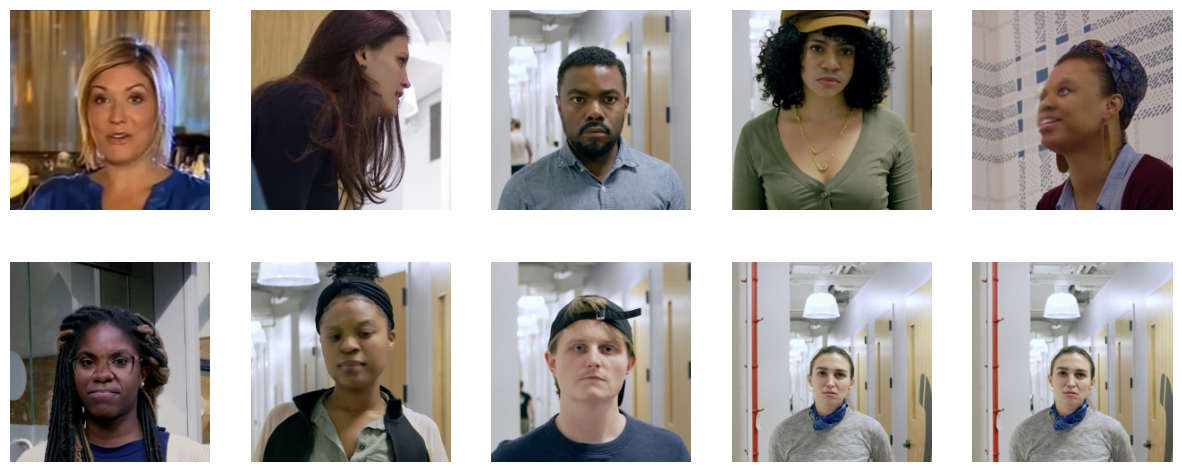

In [10]:
rand = np.random.randint(0, subset.size - 1, 10)
plt.figure(figsize=(15, 6))
for idx, i in enumerate(rand):
    # 3. Create a grid of 2 rows and 5 columns. 
    # The subplot index must start at 1 and end at 10.
    plt.subplot(2, 5, idx + 1) 
    
    plt.imshow(Image.open(subset[i]))
    plt.axis('off')

In [11]:
train_df

,image_path,label,label_binary,split,video_id,frame_index,face_conf,blur_score,bbox_area_ratio
0,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,65,0.966028,56.423741,0.038623
1,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,131,0.962883,93.100425,0.035942
2,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,262,0.900004,122.675819,0.043114
3,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,327,0.913984,122.709026,0.041684
4,/home/tungdd/ml-projects/FrameForensics26/proc...,DeepFakeDetection,FAKE,train,DeepFakeDetection/15_03__kitchen_pan__DG8ITQO3,393,0.902952,113.779514,0.040838
...,...,...,...,...,...,...,...,...,...
2765,/home/tungdd/ml-projects/FrameForensics26/proc...,original,REAL,train,original/963,383,0.945801,114.879904,0.086222
2766,/home/tungdd/ml-projects/FrameForensics26/proc...,original,REAL,train,original/963,460,0.963643,121.053135,0.067223
2767,/home/tungdd/ml-projects/FrameForensics26/proc...,original,REAL,train,original/963,537,0.955981,125.843628,0.069675
2768,/home/tungdd/ml-projects/FrameForensics26/proc...,original,REAL,train,original/963,614,0.959913,114.918161,0.070502


# DATA LOADING

In [12]:
import torchvision.transforms.v2 as v2
transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((224,224)),
    v2.ToDtype(torch.float32, scale=True),
])

In [13]:
from torch.utils.data import DataLoader, Dataset
class FaceDataset(Dataset):
    def __init__(self, df, transforms = None):
        self.df = df
        self.transforms = transforms
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path'])
        label = torch.tensor(1 if row['label_binary'] == 'REAL' else 0, dtype=torch.long)
        if self.transforms:
            img = self.transforms(img)
        return img, label
    
train_dataset = FaceDataset(train_df, transforms = transforms)
val_dataset = FaceDataset(val_df, transforms = transforms)    
test_dataset = FaceDataset(test_df, transforms = transforms)    

In [14]:
batch_size = 64


train_loader = DataLoader(train_dataset, 
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=0,
                          pin_memory=True,
                          drop_last=True,
                        #   prefetch_factor=2,
                        #   persistent_workers=True
                        )

val_loader = DataLoader(val_dataset, 
                          batch_size=batch_size,
                          num_workers=0,
                          pin_memory=True,
                        #   prefetch_factor=2,
                        #   persistent_workers=True
                        )
test_loader = DataLoader(test_dataset, 
                          batch_size=batch_size,
                          num_workers=0,
                          pin_memory=True,
                        #   prefetch_factor=2,
                        #   persistent_workers=True
                        )

In [ ]:
class FaceModel(L.LightningModule):
    def __init__(self, lr, criterion):
        super().__init__()
        self.backbone = torchvision.models.mobilenet_v3_small(weights='DEFAULT')
        self.backbone.classifier[3] = nn.Linear(1024, 2)
        self.example_input_array = torch.Tensor(8, 3, 224, 224)
        self.criterion = criterion
        self.lr = lr
        self.history = {
                    'train_loss': [],
                    'val_loss' : [],
                    'train_acc' : [],
                    'val_acc' : [],
                    'train_f1' : [],
                    'val_f1' : [],
                }
                
        self.train_preds, self.train_labels, self.train_losses = [], [],[]
        self.val_preds, self.val_labels, self.val_losses = [], [],[]
        
        self.test_preds, self.test_labels, self.test_losses = [], [],[]
    def forward(self, x):
        x = self.backbone(x)
        return x
    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
            
        self.train_preds.append(preds.detach().cpu().numpy())
        self.train_labels.append(labels.detach().cpu().numpy())
        self.train_losses.append(loss.detach().cpu())
        step_acc = (preds == labels).sum() / len(labels)
        self.log_dict({'train_loss': loss, 'train_acc': step_acc}, prog_bar=True)
        return loss
    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        
        preds = torch.argmax(outputs, dim=1)
        self.val_preds.append(preds.detach().cpu().numpy())
        self.val_labels.append(labels.detach().cpu().numpy())
        self.val_losses.append(loss.detach().cpu())
        step_acc = (preds == labels).sum() / len(labels)
        self.log_dict({'val_loss_step': loss, 'val_acc': step_acc}, prog_bar=True, on_step = True)
    
    def test_step(self, batch, batch_idx):
        images, labels = batch
         
        p1 = self(images)
        p2 = self(torch.flip(images, dims=[3]))
        p3 = self(torch.flip(images, dims=[3]))
        p4 = self(torch.rot90(images, k=1, dims=[2, 3]))
            
        avg_probs = F.softmax((p1 + p2 + p3 + p4) / 4.0, dim=1)
        preds = torch.argmax(avg_probs, dim=1)
            
        self.test_preds.append(preds.detach().cpu().numpy())
        self.test_labels.append(labels.detach().cpu().numpy())
        step_acc = (preds == labels).sum() / len(labels)
    def on_train_epoch_end(self):
        #calculate metrics
        all_preds = np.concat(self.train_preds)
        all_labels = np.concat(self.train_labels)
        train_loss = torch.stack(self.train_losses).mean()
        train_acc = (all_preds == all_labels).sum() / len(all_labels)
        train_f1 = f1_score(all_labels, all_preds, average='macro')
        
        self.train_preds = []
        self.train_labels = []
        self.train_losses = []
        
        self.history['train_loss'].append(train_loss.item())
        self.history['train_acc'].append(train_acc)
        self.history['train_f1'].append(train_f1)
        self.print(f"Epoch {self.current_epoch+1}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro-F1: {train_f1:.4f}")
    def on_validation_epoch_end(self):
        #calculate metrics
        all_preds = np.concat(self.val_preds)
        all_labels = np.concat(self.val_labels)
        val_loss = torch.stack(self.val_losses).mean()
        val_acc = (all_preds == all_labels).sum() / len(all_labels)
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        
        self.val_preds = []
        self.val_labels = []
        self.val_losses = []
        self.history['val_loss'].append(val_loss)
        self.history['val_acc'].append(val_acc)
        self.history['val_f1'].append(val_f1)
        self.log_dict({'val_loss': val_loss, 'val_f1': val_f1})
        self.print(f"          Val Loss :  {val_loss:.4f}  |  Val Acc :  {val_acc:.4f}  |  Val Macro-F1 : {val_f1:.4f}")
        self.save_hyperparameters(ignore=['criterion'])
    def on_test_epoch_end(self):
        #calculate metrics
        all_preds = np.concat(self.test_preds)
        all_labels = np.concat(self.test_labels)
        test_acc = (all_preds == all_labels).sum() / len(all_labels)
        test_f1 = f1_score(all_labels, all_preds, average='macro')
        
        self.test_preds = []
        self.test_labels = []
        self.print(f"Test Acc :  {test_acc:.4f}  |  Test Macro-F1 : {test_f1:.4f}")
        self.save_hyperparameters(ignore=['criterion'])
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr = self.lr, weight_decay=1e-4)
            # Smoothly decay the LR down to 1e-5 over the 100 epochs
        # scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)
        return optimizer
        # return {"optimizer": optimizer, "lr_scheduler": scheduler}
        # # OneCycleLR handles both the Warmup and the Cosine Decay automatically!
        # scheduler = OneCycleLR(
        #     optimizer, 
        #     max_lr=1e-3, 
        #     total_steps=self.trainer.estimated_stepping_batches, 
        #     pct_start=0.1 # Spend first 10% of training warming up
        # )
        # return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "interval": "step"}}

In [16]:
# import shutil

# folder_path = 'checkpoints'
# shutil.rmtree(folder_path)


In [17]:
LR = 1e-5
criterion = nn.CrossEntropyLoss()#label_smoothing=0.1)#, weights = class_weights)
model = FaceModel(lr = LR, criterion=criterion)


In [18]:
from pytorch_lightning.tuner import Tuner
import matplotlib.pyplot as plt

# 1. Initialize your model and trainer normally # It starts with your default LR
trainer = L.Trainer(max_epochs=60,
                   precision='16-mixed',
                   #profiler='simple',
                   log_every_n_steps=1 )

# # 2. Create the Tuner
# tuner = Tuner(trainer)

# # 3. Run the Learning Rate Finder
# print("Running LR Finder...")
# lr_finder = tuner.lr_find(
#     model, 
#     train_dataloaders=train_loader, 
#     min_lr=1e-6, 
#     max_lr=0.1, 
#     num_training=100, # Test 100 different LRs
# )
# #tuner.scale_batch_size(model, datamodule=datamodule, mode="power")
# # 4. Get the mathematically optimal LR
# suggested_lr = lr_finder.suggestion()
# print(f"🔥 Auto-Suggested Learning Rate: {suggested_lr:.6f}")

# # 5. (Optional but highly recommended) Plot the curve!
# fig = lr_finder.plot(suggest=True)
# plt.show()
# #model.history = {
# #    'train_loss': [],
# #    'val_loss' : [],
# #    'train_acc' : [],
#  #   'val_acc' : [],
#  #   'train_f1' : [],
# #    'val_f1' : [],
# #}

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/tungdd/jupyter-pyenvs/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [19]:
trainer.test(model, test_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tungdd/jupyter-pyenvs/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/tungdd/jupyter-pyenvs/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many wo

Testing: |                                                                                                    …

Test Acc :  0.6629  |  Test Macro-F1 : 0.3987


[{}]

In [20]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, TQDMProgressBar, StochasticWeightAveraging
checkpoint_callback = ModelCheckpoint(
    save_top_k=3,
    monitor="val_f1",
    mode="max",
    dirpath="/home/tungdd/ml-projects/FrameForensics26/workspace/checkpoints",
    filename="best_model-{epoch:02d}-val_f1:{val_f1:.4f}",
)
tqdm_bar = TQDMProgressBar(refresh_rate=1)
trainer = L.Trainer(max_epochs=100,
                    #profiler="simple",
                    #accumulate_grad_batches=4,
                    #fast_dev_run=True,
                    precision="16-mixed",
                    log_every_n_steps=1,
                    #overfit_batches=1,
                    callbacks=[
                        EarlyStopping(monitor='val_f1', patience=15, mode='max', strict=True, verbose=True),
                        checkpoint_callback, tqdm_bar,
                        #StochasticWeightAveraging(swa_lrs=5e-5)
                    ])
trainer.fit(model, train_dataloaders=train_loader,val_dataloaders=val_loader)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tungdd/jupyter-pyenvs/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type             | Params | Mode  | FLOPs | In sizes         | Out sizes
----------------------------------------------------------------------------------------------
0 | backbone  | MobileNetV3      | 1.5 M  | train | 887 M | [8, 3, 224, 224] | [8, 2]   
1 | criterion | CrossEntropyLoss | 0      | train | 0     | ?           

Sanity Checking: |                                                                                            …

/home/tungdd/jupyter-pyenvs/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/tungdd/jupyter-pyenvs/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


          Val Loss :  0.6309  |  Val Acc :  0.6875  |  Val Macro-F1 : 0.4511


/home/tungdd/jupyter-pyenvs/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/tungdd/jupyter-pyenvs/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


...

Validation: |                                                                                                 …

          Val Loss :  0.0332  |  Val Acc :  0.9848  |  Val Macro-F1 : 0.9771
Epoch 38: Train Loss: 0.0023 | Train Acc: 1.0000 | Train Macro-F1: 1.0000


Validation: |                                                                                                 …

Monitored metric val_f1 did not improve in the last 15 records. Best score: 0.977. Signaling Trainer to stop.


          Val Loss :  0.0326  |  Val Acc :  0.9848  |  Val Macro-F1 : 0.9771
Epoch 39: Train Loss: 0.0021 | Train Acc: 1.0000 | Train Macro-F1: 1.0000


In [22]:
os.listdir('/home/tungdd/ml-projects/FrameForensics26/workspace/checkpoints')

['best_model-epoch=23-val_f1:val_f1=0.9771.ckpt',
 'best_model-epoch=24-val_f1:val_f1=0.9771.ckpt',
 'best_model-epoch=25-val_f1:val_f1=0.9771.ckpt']

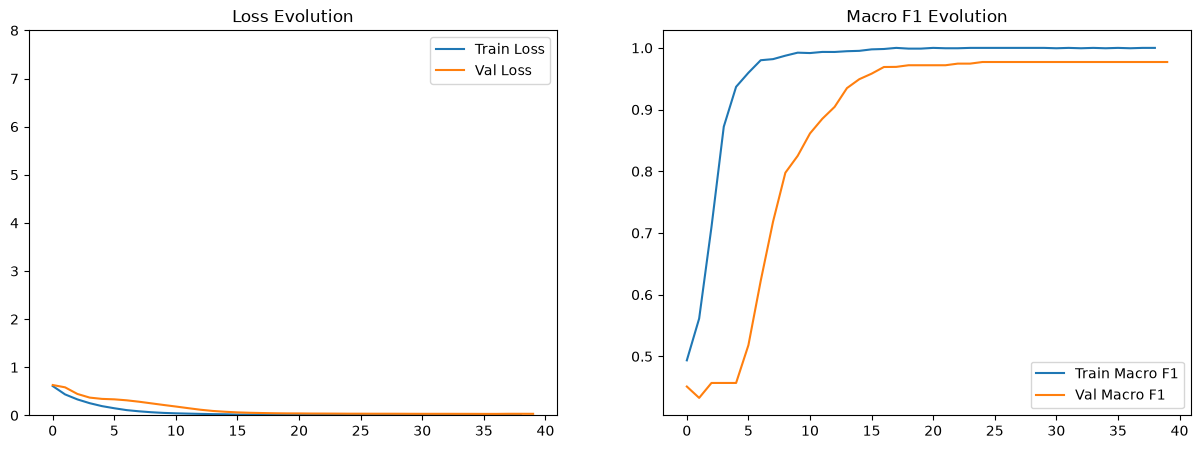


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       126
           1       0.99      0.99      0.99       466

    accuracy                           0.98       592
   macro avg       0.98      0.97      0.98       592
weighted avg       0.98      0.98      0.98       592

0.9729715920703045


In [29]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def plot_training_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot Loss
    ax[0].plot(history['train_loss'], label='Train Loss')
    ax[0].plot(history['val_loss'], label='Val Loss')
    ax[0].set_title('Loss Evolution')
    ax[0].set_ylim(0,8)
    ax[0].legend()
    
    # Plot F1
    ax[1].plot(history['train_f1'], label='Train Macro F1')
    ax[1].plot(history['val_f1'], label='Val Macro F1')
    ax[1].set_title('Macro F1 Evolution')
    ax[1].legend()
    
    plt.show()

def full_evaluation(model, loader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 1. Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds))
    print(roc_auc_score(all_labels, all_preds))
    # # 2. Confusion Matrix
    # cm = confusion_matrix(all_labels, all_preds)
    # plt.figure(figsize=(10, 8))
    # sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    # plt.xlabel('Predicted')
    # plt.ylabel('Actual')
    # plt.title('Confusion Matrix')
    # plt.show()

checkpoint = torch.load('/home/tungdd/ml-projects/FrameForensics26/workspace/checkpoints/best_model-epoch=24-val_f1:val_f1=0.9771.ckpt')
model.load_state_dict(checkpoint['state_dict'])
model.to(device)
model.eval()

# Execution
plot_training_history(model.history)
full_evaluation(model, val_loader, device, range(0,150))

In [27]:
from IPython.display import FileLink
FileLink('/home/tungdd/ml-projects/FrameForensics26/workspace/checkpoints/best_model-epoch=24-val_f1:val_f1=0.9771.ckpt')

/home/tungdd/ml-projects/FrameForensics26/workspace/checkpoints/best_model-epoch=24-val_f1:val_f1=0.9771.ckpt